# Project 15: Speech Emotion Recognition - Data Inspection & EDA

**Objective:**
The goal of this notebook is to perform an initial data exploration of the audio dataset. According to the project requirements, we need to analyze the dataset structure and visualize acoustic features (waveforms, spectrograms, MFCCs) to understand the differences between emotions.

**Key Tasks:**
1. Load audio file paths.
2. Extract metadata (Emotions, Intensity, Actors).
3. Visualize Class Distribution (Check for imbalance).
4. **Compare "Happy" vs. "Angry" signals** (Time-domain and Frequency-domain).

In [6]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd

# Configuration for plots
plt.style.use('ggplot')
sns.set_palette("husl")

## 1. Load File Paths
We define the paths to the raw data and list all `.wav` files.

In [7]:
ROOT_DIR = Path.cwd().parent
DATA_RAW_DIR = ROOT_DIR / "data" / "raw" # Or 'processed' depending on which one you want to inspect
DATA_PROCESSED_DIR = ROOT_DIR / "data" / "processed"

def ensure_paths(paths):
    for p in paths:
        if not p.exists():
            print(f"Warning: Path {p} does not exist.")

ensure_paths([DATA_RAW_DIR])

audio_files = list(DATA_RAW_DIR.rglob("*.wav")) # Load audio files using pathlib

print(f"Total audio files found: {len(audio_files)}")
print(f"Example path: {audio_files[0] if audio_files else 'No files found'}")

Total audio files found: 2880
Example path: C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_01\03-01-01-01-01-01-01.wav


## 2. Metadata Extraction & DataFrame Creation
To analyze the data, we need to parse the filenames.

**RAVDESS Convention Example:** `03-01-05-01-01-01-01.wav`
* 05 = Emotion (03=Happy, 05=Angry)

In [8]:
# Emotion mapping: 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

data_list = []

for file_path in audio_files:
    filename = file_path.name
    parts = filename.split('-')

    # Safety check: ensure filename matches expected pattern length
    if len(parts) >= 3:
        emotion_code = parts[2]
        actor_id = parts[-1].split('.')[0] # Last part usually actor
        
        data_list.append({
            'path': str(file_path),
            'filename': filename,
            'emotion_code': emotion_code,
            'emotion': emotion_map.get(emotion_code, 'unknown'),
            'actor': actor_id
        })

df = pd.DataFrame(data_list)
df.head()

,path,filename,emotion_code,emotion,actor
0,C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_...,03-01-01-01-01-01-01.wav,01,neutral,01
1,C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_...,03-01-01-01-01-02-01.wav,01,neutral,01
2,C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_...,03-01-01-01-02-01-01.wav,01,neutral,01
3,C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_...,03-01-01-01-02-02-01.wav,01,neutral,01
4,C:\GitHub\Repositories\TUW-IDL\data\raw\Actor_...,03-01-02-01-01-01-01.wav,02,calm,01


## 3. Exploratory Data Analysis (EDA)
We need to check if the dataset is balanced. [cite_start]An imbalanced dataset might require augmentation strategies later.

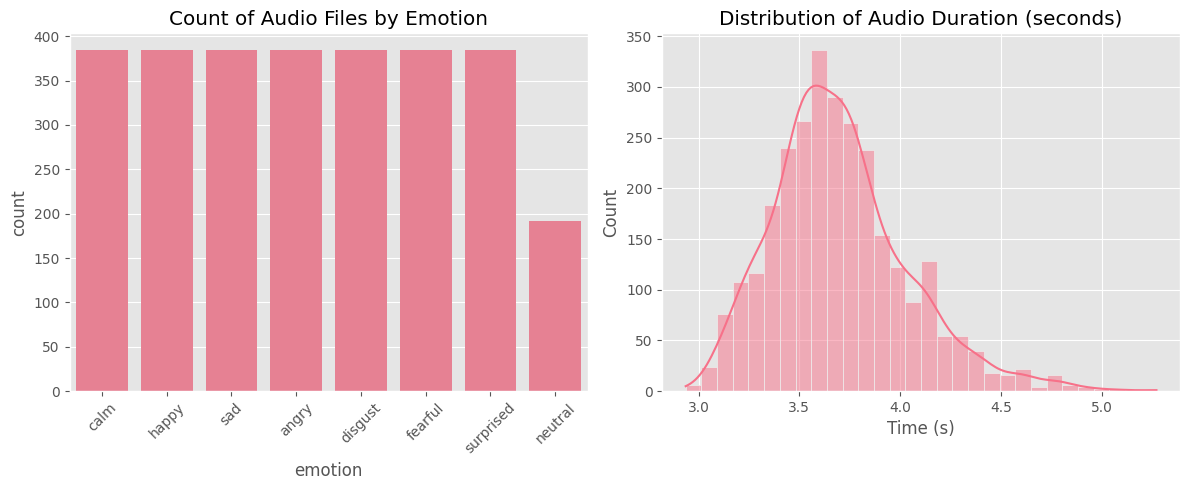

In [9]:
plt.figure(figsize=(12, 5))

# Plot Emotion Counts
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title('Count of Audio Files by Emotion')
plt.xticks(rotation=45)

# Calculate durations for a subset (to save time) or all files
durations = []
# Sampling files
for p in df['path']:
    y, sr = librosa.load(p, sr=None)
    durations.append(len(y) / sr)

plt.subplot(1, 2, 2)
sns.histplot(durations, kde=True, bins=30)
plt.title('Distribution of Audio Duration (seconds)')
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 4. Visualizing "Happy" vs "Angry"
This is crucial for your report. We will look at:
1.  **Waveform:** Amplitude over time.
2.  **Mel-Spectrogram:** Frequency energy over time (mimics human hearing). [cite_start]This is the standard input for CNN models in SER[cite: 6].

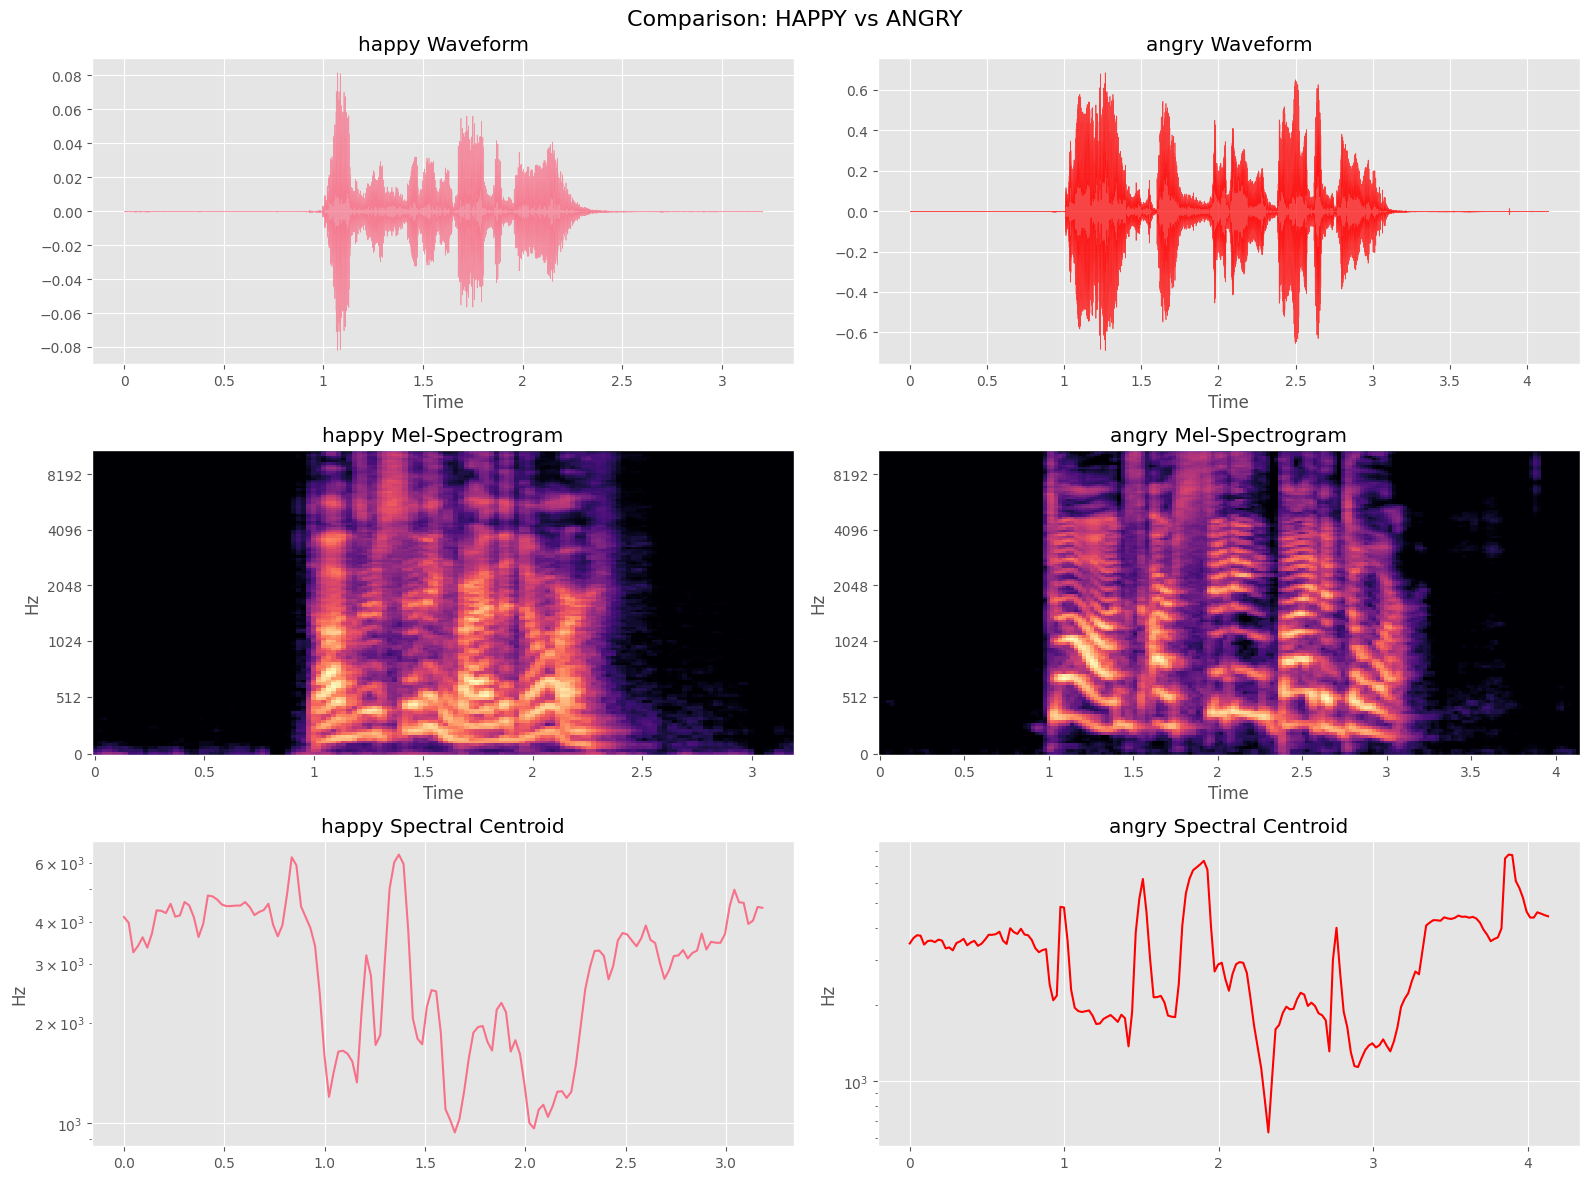

Audio 1 (happy):


Audio 2 (angry):


In [5]:
def plot_comparison(emotion1, emotion2, df):
    # Select one random file for each emotion
    file1 = df[df['emotion'] == emotion1].sample(1).iloc[0]['path']
    file2 = df[df['emotion'] == emotion2].sample(1).iloc[0]['path']

    # Load Audio
    y1, sr1 = librosa.load(file1)
    y2, sr2 = librosa.load(file2)

    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle(f'Comparison: {emotion1.upper()} vs {emotion2.upper()}', fontsize=16)

    # 1. Waveforms
    librosa.display.waveshow(y1, sr=sr1, ax=axes[0, 0], alpha=0.7)
    axes[0, 0].set_title(f'{emotion1} Waveform')

    librosa.display.waveshow(y2, sr=sr2, ax=axes[0, 1], alpha=0.7, color='r')
    axes[0, 1].set_title(f'{emotion2} Waveform')

    # 2. Mel-Spectrograms (Log scale)
    # Log-mel features are preferred for SER
    S1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128)
    S1_dB = librosa.power_to_db(S1, ref=np.max)
    img1 = librosa.display.specshow(S1_dB, x_axis='time', y_axis='mel', sr=sr1, ax=axes[1, 0])
    axes[1, 0].set_title(f'{emotion1} Mel-Spectrogram')

    S2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128)
    S2_dB = librosa.power_to_db(S2, ref=np.max)
    img2 = librosa.display.specshow(S2_dB, x_axis='time', y_axis='mel', sr=sr2, ax=axes[1, 1])
    axes[1, 1].set_title(f'{emotion2} Mel-Spectrogram')

    # 3. Spectral Centroid (Brightness/Tone)
    # Good for showing "sharpness" of angry vs happy voices
    cent1 = librosa.feature.spectral_centroid(y=y1, sr=sr1)
    times1 = librosa.times_like(cent1)
    axes[2, 0].semilogy(times1, cent1.T, label='Spectral Centroid')
    axes[2, 0].set_ylabel('Hz')
    axes[2, 0].set_title(f'{emotion1} Spectral Centroid')

    cent2 = librosa.feature.spectral_centroid(y=y2, sr=sr2)
    times2 = librosa.times_like(cent2)
    axes[2, 1].semilogy(times2, cent2.T, color='r', label='Spectral Centroid')
    axes[2, 1].set_ylabel('Hz')
    axes[2, 1].set_title(f'{emotion2} Spectral Centroid')

    plt.tight_layout()
    plt.show()

    print(f"Audio 1 ({emotion1}):")
    ipd.display(ipd.Audio(file1))

    print(f"Audio 2 ({emotion2}):")
    ipd.display(ipd.Audio(file2))

# Execute comparison
plot_comparison('happy', 'angry', df)

## 5. Observations from Visualization

Based on the comparison between the "Happy" and "Angry" samples above, we can observe distinct acoustic signatures that our model needs to learn:

* **Amplitude & Energy (Waveform):**
    * **Drastic Scale Difference:** The most striking difference is the amplitude. The "Happy" signal peaks around **0.08**, whereas the "Angry" signal reaches **0.60**.
    * **Implication:** "Angry" speech in this dataset is significantly louder. Our preprocessing pipeline must handle **normalization** carefully; otherwise, the model might learn to classify "Angry" solely based on volume rather than emotional timbre.

* **Frequency & Texture (Mel-Spectrogram):**
    * **Texture (Happy):** The "Happy" spectrogram appears **"brighter" and more continuous**. This suggests a smoother prosody with sustained vowels (longer horizontal energy bands).
    * **Texture (Angry):** The "Angry" spectrogram is characterized by distinct **vertical striations** (lines). This reflects an aggressive, "staccato" speaking style with sharp, explosive onsets and sudden stops, rather than a smooth melodic contour.
    * **Frequency Range:** While the "Happy" sample looks denser, the "Angry" energy bursts often extend vertically into higher frequencies (tall spikes), indicating the "sharpness" or "harshness" of the voice.

* **Timbre (Spectral Centroid):**
    * The **Spectral Centroid** (red line in the bottom plots) represents the "center of mass" of the sound spectrum.
    * For **Angry**, the centroid stays consistently higher (often above 3000-4000 Hz) and has sharp, sustain peaks.
    * For **Happy**, the centroid fluctuates more significantly and dips lower, reflecting the varied prosody of a happy sentence versus the sustained tension of anger.

* **Preprocessing Note:** Both files show significant silence at the beginning (t=0 to t=1.0s). This confirms the need for **trimming/stripping silence** in our `AudioWaveformPreprocessor` to ensure the model focuses only on the speech content.